In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw

plt.rcParams['figure.dpi'] = 300

In [2]:
# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS_ORIGINAL = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
PATH_TO_DOCKING_RESULTS_REAL = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [3]:
# import random
# random.seed(42)
# POCKETS_TO_ANALYZE = set(random.sample([f'{i.replace(".pdb", "")}_pocket_{j}' for i,j in zip(pocket_detection_data['File name'], pocket_detection_data['Pocket number'])], 10))

In [4]:
DOCKING_RESULTS_ORIGINAL = {}
DOCKING_RESULTS_REAL = {}
DOCKING_RESULTS_REAL_BACKGROUND = {}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_ORIGINAL))[:]):
    # if pocket in POCKETS_TO_ANALYZE:
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_ORIGINAL, pocket, 'report.csv'))
        DOCKING_RESULTS_ORIGINAL[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL))[:]):
    # if pocket in POCKETS_TO_ANALYZE:
        try:
            scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL, pocket, 'report.csv'))
            DOCKING_RESULTS_REAL[pocket] = {i: j for i, j in zip(scores['compound'][:100000], scores['score'][:100000])}
            DOCKING_RESULTS_REAL_BACKGROUND[pocket] = {i: j for i, j in zip(scores['compound'][100000:], scores['score'][100000:])}
        except:
            pass

100%|██████████| 276/276 [05:22<00:00,  1.17s/it]


In [5]:
print(len(DOCKING_RESULTS_ORIGINAL['alphafold3_P9WFT1_model_4_pocket_2']))
print(len(DOCKING_RESULTS_REAL['alphafold3_P9WFT1_model_4_pocket_2']))
print(len(DOCKING_RESULTS_REAL_BACKGROUND['alphafold3_P9WFT1_model_4_pocket_2']))

100154
100000
12958


In [6]:
def simple_boxplot(ax, x, y, c, width):
    lw = 0.2
    lw = 0.35  # only for the reduced version
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[0, 100], showfliers=False,
               boxprops=dict(facecolor=c, color='black', lw=lw),
               medianprops=dict(color='black', lw=lw),
               whiskerprops=dict(color='black', lw=lw),
               capprops=dict(color='none', lw=lw))
    
def simple_boxplot_label(ax, x, y, c, width, label):
    lw = 0.35
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[0, 100], showfliers=False, label=label,
               boxprops=dict(facecolor=c, color='black', lw=lw),
               medianprops=dict(color='black', lw=lw),
               whiskerprops=dict(color='black', lw=lw),
               capprops=dict(color='none', lw=lw))

In [7]:
ind = np.argsort([np.median(list(DOCKING_RESULTS_ORIGINAL[x].values())) for x in sorted(DOCKING_RESULTS_ORIGINAL)])

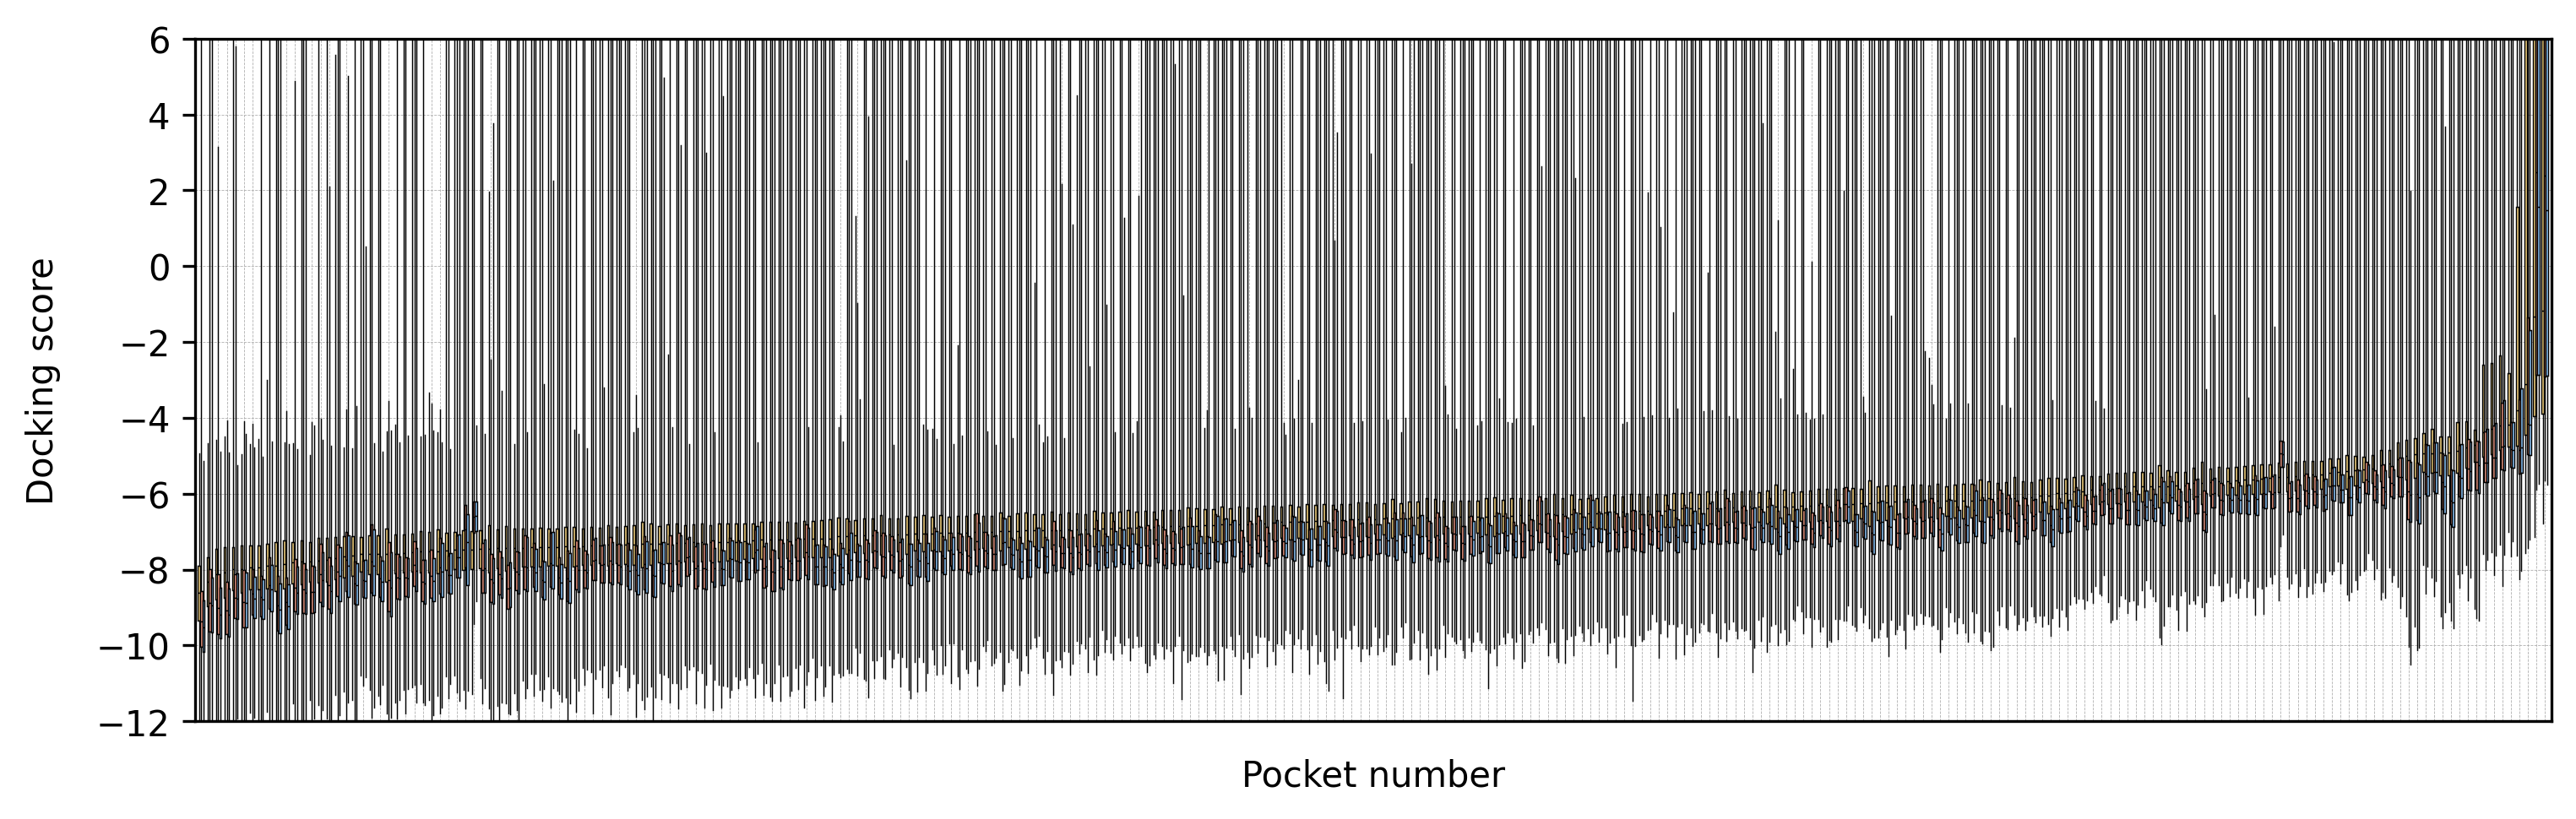

In [8]:
fig, ax = plt.subplots(figsize=(12, 3.5))

for c, pock in enumerate(np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind]):
    w = 0.25
    simple_boxplot(ax, c-w, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w)
    simple_boxplot(ax, c, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w)
    simple_boxplot(ax, c+w, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w)

# plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], [pock.replace("_model", "\nmodel") for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], ["" for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Docking score", labelpad=10)
plt.ylim([-12, 6])
plt.show()

In [9]:
len(DOCKING_RESULTS_ORIGINAL[pock])

100154

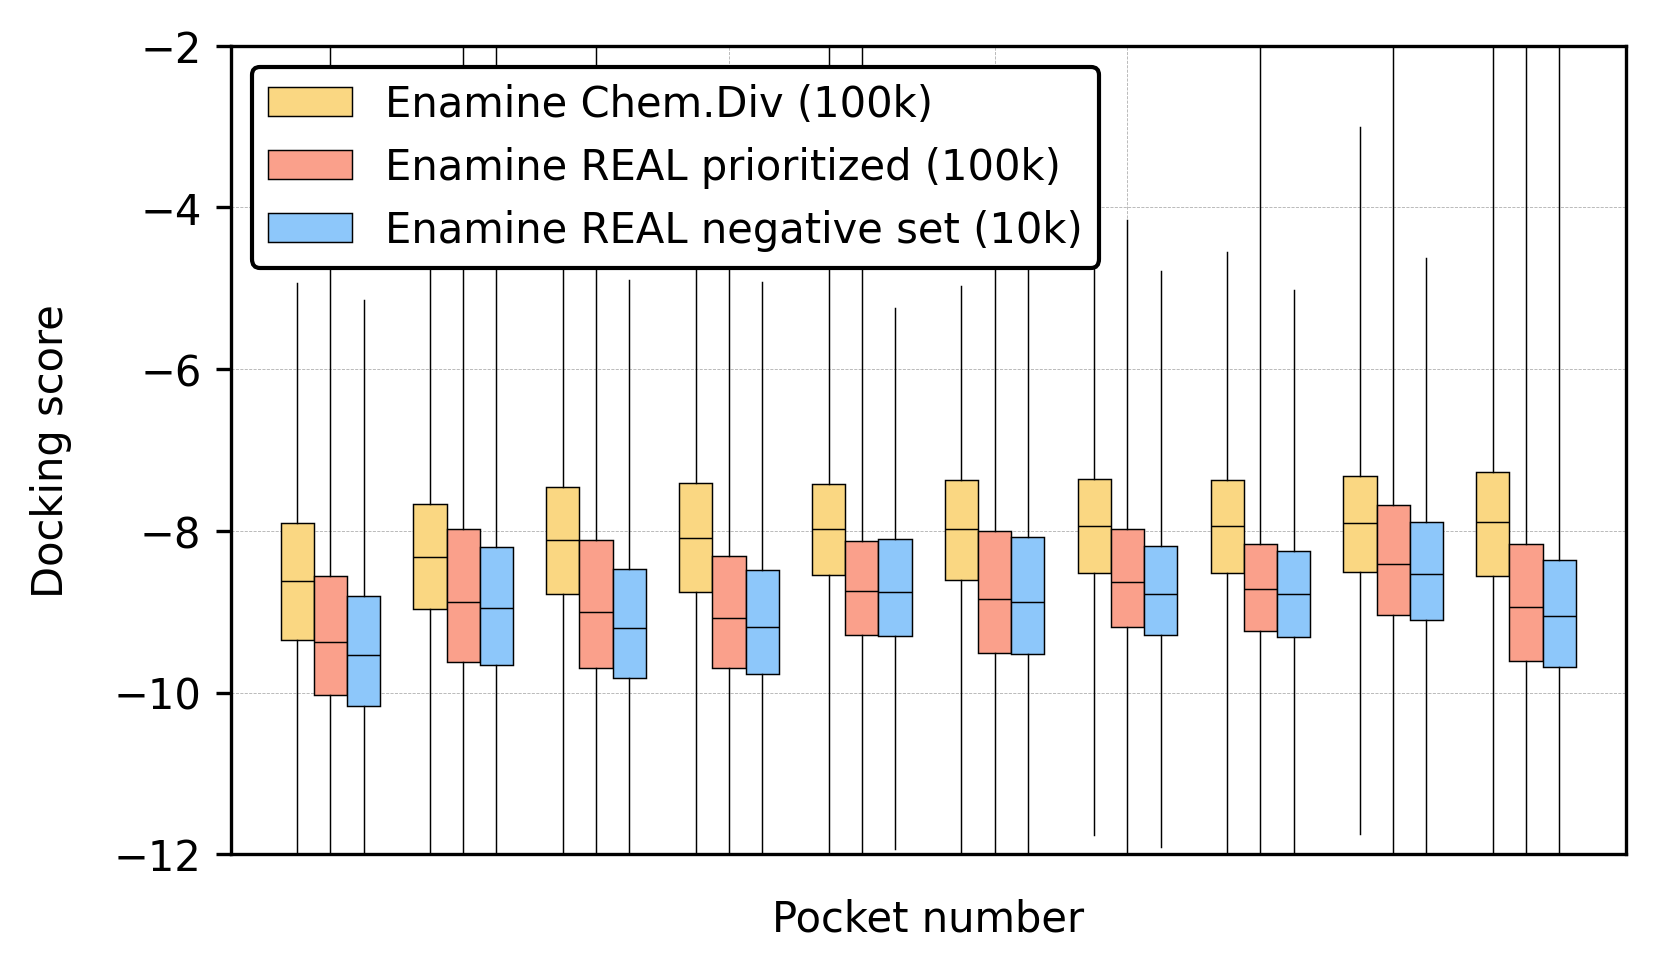

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))

for c, pock in enumerate(np.array(sorted(DOCKING_RESULTS_ORIGINAL))[ind][:10]):
    w = 0.25
    if c != 0:
        simple_boxplot(ax, c-w, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w)
        simple_boxplot(ax, c, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w)
        simple_boxplot(ax, c+w, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w)
    else:
        simple_boxplot_label(ax, c-w, DOCKING_RESULTS_ORIGINAL[pock].values(), c="#FAD782", width=w, label=f"Enamine Chem.Div (100k)")
        simple_boxplot_label(ax, c, DOCKING_RESULTS_REAL[pock].values(), c="#FAA08B", width=w, label="Enamine REAL prioritized (100k)")
        simple_boxplot_label(ax, c+w, DOCKING_RESULTS_REAL_BACKGROUND[pock].values(), c="#8DC7FA", width=w, label="Enamine REAL negative set (10k)")

# plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))], [pock.replace("_model", "\nmodel") for i in sorted(DOCKING_RESULTS_ORIGINAL)], rotation=30, ha='right', size=7)
plt.xticks([i for i in range(len(DOCKING_RESULTS_ORIGINAL))][:10], ["" for i in sorted(DOCKING_RESULTS_ORIGINAL)][:10], rotation=30, ha='right', size=7)
plt.tick_params(axis='x', length=0)
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Docking score", labelpad=10)
plt.legend(framealpha=1, edgecolor='k')
plt.ylim([-12, -2])
plt.show()

In [11]:
POCKET_TO_ANALYZE = set(["swissmodel_P9WFW1_model_1_pocket_1"])

In [12]:
print("Reading inference results")
PATH_TO_INFERENCES = "/aloy/home/acomajuncosa/Ersilia/mtb/processed/unidock_docking/inferences"

# For each pocket
for pocket in sorted(os.listdir(PATH_TO_INFERENCES)):
    if pocket.replace("_bin_01.csv.gz", "") in POCKET_TO_ANALYZE:
        print(f"Processing {pocket} ...")
        # Load results
        inf = pd.read_csv(os.path.join(PATH_TO_INFERENCES, pocket))
        inf = {i: j for i,j in zip(inf['ids'], inf['probs'])}
        values = np.array([inf[i] for i in inf])
        ids = np.array([i for i in inf])
        break

Reading inference results
Processing swissmodel_P9WFW1_model_1_pocket_1_bin_01.csv.gz ...


In [13]:
# Top 100k
top_100_000 = np.argpartition(values, -100_000)[-100_000:]
top_100_000 = top_100_000[np.argsort(values[top_100_000])[::-1]]

# Top 10k
top_10_000 = np.argpartition(values, -10_000)[-10_000:]
top_10_000 = top_10_000[np.argsort(values[top_10_000])[::-1]]

# Top 1k
top_1_000 = np.argpartition(values, -1_000)[-1_000:]
top_1_000 = top_1_000[np.argsort(values[top_1_000])[::-1]]

In [14]:
thrs = [i for i in np.arange(-0.01, 1.02, 0.01)]
y, y_100k, y_10k, y_1k = [], [], [], []

for thr in thrs:
    y.append(len(np.where(values < thr)[0]) / len(values))
    y_100k.append(len(np.where(values[top_100_000] < thr)[0]) / len(values[top_100_000]))
    y_10k.append(len(np.where(values[top_10_000] < thr)[0]) / len(values[top_10_000]))
    y_1k.append(len(np.where(values[top_1_000] < thr)[0]) / len(values[top_1_000]))


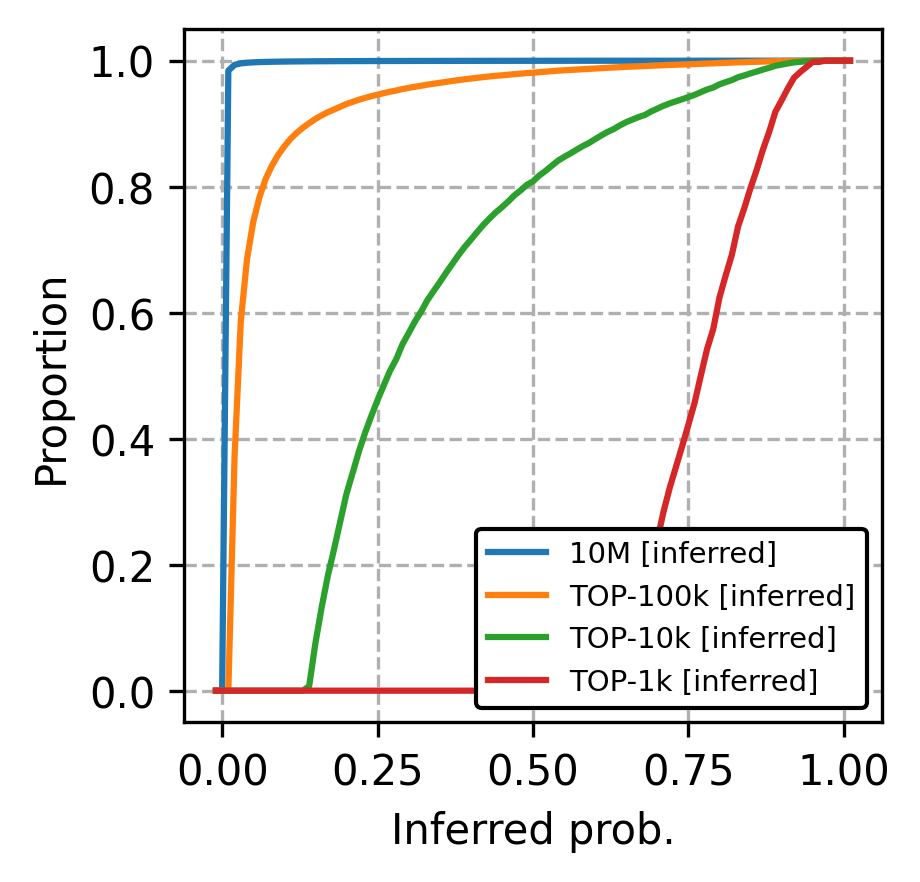

In [15]:
plt.figure(figsize=(3, 3))

plt.plot(thrs, y, label='10M [inferred]')
plt.plot(thrs, y_100k, label='TOP-100k [inferred]')
plt.plot(thrs, y_10k, label='TOP-10k [inferred]')
plt.plot(thrs, y_1k, label='TOP-1k [inferred]')

plt.legend(framealpha=1, loc='lower right', edgecolor='k', prop={'size': 7})
plt.ylabel("Proportion")
plt.xlabel("Inferred prob.")
plt.grid(linestyle='--')
plt.show()

In [16]:
# Add filtering step
POCKET_TO_ANALYZE = list(POCKET_TO_ANALYZE)[0]

In [20]:
root = "."

# Get input ligands
PATH_TO_INPUT_LIGANDS_FILES = os.path.join(root, "..", "processed", "unidock_REAL_docking", "input_ligands")
input_ligands = open(os.path.join(PATH_TO_INPUT_LIGANDS_FILES, f"input_ligands_{POCKET_TO_ANALYZE}.txt"), "r").readlines()
input_ligands = [i.strip().replace(".sdf", "").split("/")[-1] for i in input_ligands]

# Divide in actives and inactives
actives = input_ligands[:100_000]
inactives = input_ligands[100_000:]
del input_ligands

# Get values
active_values = np.array([inf[i] for i in actives])
inactive_values = np.array([inf[i] for i in inactives])

In [54]:
thrs = [i for i in np.arange(-0.01, 1.02, 0.01)]
y, y_100k, y_10k, y_actives, y_actives_top10k, y_inactives = [], [], [], [], [], []

for thr in thrs:
    y.append(len(np.where(values < thr)[0]) / len(values))
    y_100k.append(len(np.where(values[top_100_000] < thr)[0]) / len(values[top_100_000]))
    y_10k.append(len(np.where(values[top_10_000] < thr)[0]) / len(values[top_10_000]))
    y_actives.append(len(np.where(active_values < thr)[0]) / len(active_values))
    y_actives_top10k.append(len(np.where(active_values[:10000] < thr)[0]) / len(active_values[:10000]))
    y_inactives.append(len(np.where(inactive_values < thr)[0]) / len(inactive_values))
    

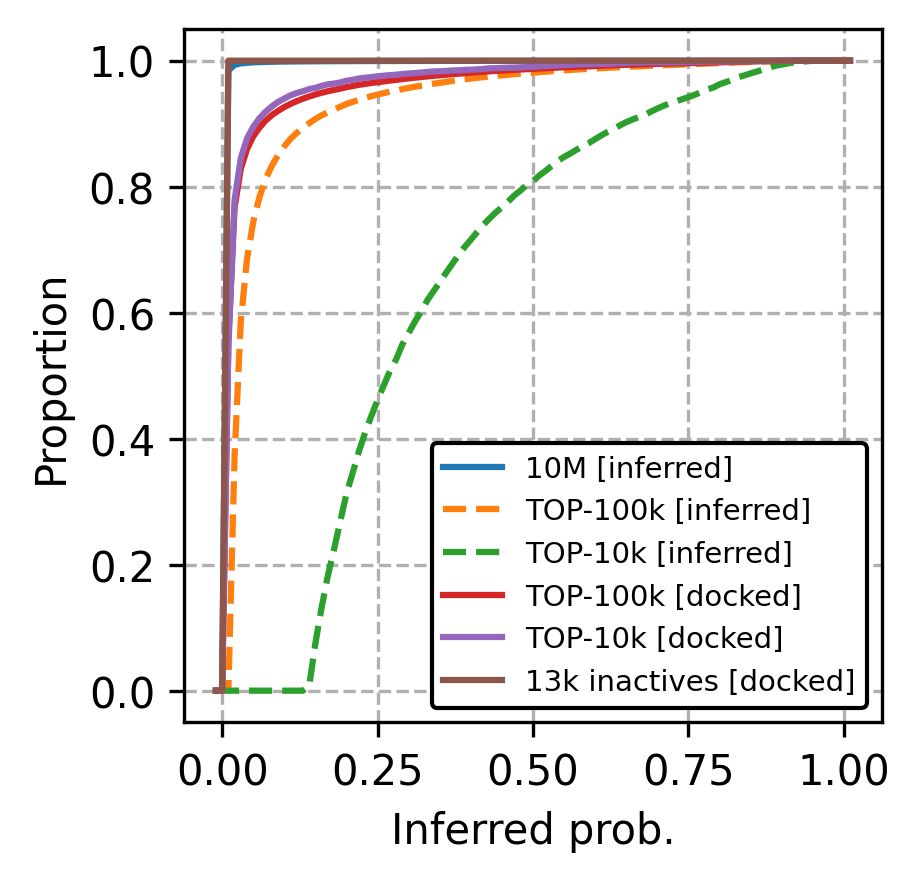

In [57]:
plt.figure(figsize=(3, 3))

plt.plot(thrs, y, label='10M [inferred]')
plt.plot(thrs, y_100k, label='TOP-100k [inferred]', linestyle='--')
plt.plot(thrs, y_10k, label='TOP-10k [inferred]', linestyle='--')
plt.plot(thrs, y_actives, label='TOP-100k [docked]')
plt.plot(thrs, y_actives_top10k, label='TOP-10k [docked]')
plt.plot(thrs, y_inactives, label='13k inactives [docked]')

plt.legend(framealpha=1, loc='lower right', edgecolor='k', prop={'size': 7})
plt.ylabel("Proportion")
plt.xlabel("Inferred prob.")
plt.grid(linestyle='--')
plt.show()

In [58]:
# Correlation inference prob & docking score

In [61]:
x, y = [], []
for act in actives:
    x.append(inf[act])
    y.append(DOCKING_RESULTS_REAL[POCKET_TO_ANALYZE][act])

KeyError: 's_40____13315642____11677966'

In [66]:
POCKET_TO_ANALYZE

'swissmodel_P9WFW1_model_1_pocket_1'

In [64]:
len(DOCKING_RESULTS_REAL[POCKET_TO_ANALYZE])

100000